# Task Dataset Build

Builds a focused species-detector dataset

- clips from target species : XC or ebird
- clips per other-present species (pooled into `non_target`)
- AudioSet ambient clips (pooled into `non_target`)

All downloads are cached: re-running the notebook only fetches what's missing.

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from pathlib import Path

import pyrootutils

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

# Parameters

In [16]:
from building.geographic_task import cascading_slug, task_slug

LAT, LON = 48.8566, 2.3522 # PARIS
RADIUS_KM = 50

TARGET_SPECIES = [
    "Emberiza calandra",
    "Hippolais polyglotta",
    "Regulus ignicapilla",
]

TARGET_CLIPS_PER_SPECIES = 5000
NON_TARGET_CLIPS_PER_SPECIES = 300

# Area discovery (matches analysis.ipynb defaults)
MIN_AREA_RECORDINGS = 10
ANALYSIS_MAX_BIRDNET = 500
ANALYSIS_MIN_CONF = 0.85

# AudioSet ambient/anthropic noise (diversified across ~60 FOCUS_CLASSES)
AS_CLIPS_PER_CLASS = 250
AS_MAX_TOTAL_CLIPS = 15000

# Dataset folders are slug-named so the (species, area) context is
# visible at the filesystem level and aligned with the results folder.
COLLECTION_NAME = task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM)
CASCADING_COLLECTION_NAME = cascading_slug(COLLECTION_NAME)
print(f"standard:  {COLLECTION_NAME}")
print(f"cascading: {CASCADING_COLLECTION_NAME}")

standard:  task_s3_49_2_r50
cascading: task_s3_49_2_r50_cascading


# Discover other species present in the area

In [17]:
from building.analysis import (
    area_audio_cache_dir,
    bbox_from_radius,
    birdnet_area_analysis,
    combined_species_table,
    fetch_area_recordings,
    recordings_to_df,
)

bbox = bbox_from_radius(LAT, LON, RADIUS_KM)
area_df = recordings_to_df(await fetch_area_recordings(bbox))
bn = await birdnet_area_analysis(
    area_df,
    max_recordings=ANALYSIS_MAX_BIRDNET,
    min_confidence=ANALYSIS_MIN_CONF,
    cache_dir=area_audio_cache_dir(LAT, LON, RADIUS_KM),
)
combined = combined_species_table(
    area_df, bn["detections"], min_recordings=MIN_AREA_RECORDINGS
)
OTHER_SPECIES = [
    sp for sp in combined["scientific_name"].tolist() if sp not in TARGET_SPECIES
]
print(f"{len(OTHER_SPECIES)} other species present in area")
OTHER_SPECIES

BirdNET analyse:   0%|          | 0/500 [00:00<?, ?it/s]

36 other species present in area


['Psittacula krameri',
 'Parus major',
 'Anthus spinoletta',
 'Dendrocoptes medius',
 'Curruca communis',
 'Fringilla coelebs',
 'Certhia brachydactyla',
 'Sylvia atricapilla',
 'Troglodytes troglodytes',
 'Locustella luscinioides',
 'Phylloscopus collybita',
 'Acrocephalus palustris',
 'Muscicapa striata',
 'Locustella naevia',
 'Tyto alba',
 'Erithacus rubecula',
 'Corvus corone corone',
 'Acanthis cabaret',
 'Poecile palustris',
 'Turdus philomelos',
 'Turdus merula',
 'Alcedo atthis',
 'Picus viridis',
 'Corvus corone',
 'Athene noctua',
 'Sitta europaea',
 'Cisticola juncidis',
 'Curruca undata',
 'Pica pica',
 'Sylvia borin',
 'Acrocephalus scirpaceus',
 'Cyanistes caeruleus',
 'Luscinia megarhynchos',
 'Anthus spinoletta spinoletta',
 'Dendrocopos major',
 'Falco tinnunculus']

# Long recordings for real-world evaluation

Download the N longest XC recordings in the area and cache their full BirdNET analysis. Used by `results.ipynb` to score the INT8 model on hours of unsegmented audio.

In [18]:
from building.geographic_task.long_recordings import (
    birdnet_long,
    download_long,
    long_rec_dir,
    pick_longest,
)

N_LONG_PER_SPECIES = 10

long_dir = long_rec_dir(LAT, LON, RADIUS_KM)
picks = pick_longest(area_df, TARGET_SPECIES, N_LONG_PER_SPECIES)
print(f"selected {len(picks)} recordings ({picks['length_seconds'].sum() / 60:.1f} min total)")
print(f"  cache dir: {long_dir}")
picks[["id", "scientific_name", "length_seconds"]]

selected 22 recordings (55.2 min total)
  cache dir: /home/nathan/Documents/multi-chirp/raw_dataset/long_recordings/r50km_lat48.8566_lon2.3522


,id,scientific_name,length_seconds
0,556879,Hippolais polyglotta,509
1,475261,Regulus ignicapilla,246
2,556881,Hippolais polyglotta,243
3,556872,Hippolais polyglotta,212
4,556868,Hippolais polyglotta,181
5,772554,Regulus ignicapilla,165
6,772553,Regulus ignicapilla,164
7,556870,Hippolais polyglotta,154
8,556873,Hippolais polyglotta,144
9,556866,Hippolais polyglotta,143


In [19]:
await download_long(picks, long_dir)
birdnet_long(long_dir, TARGET_SPECIES, min_confidence=0.5)

download long XC:   0%|          | 0/22 [00:00<?, ?it/s]

BirdNET long:   0%|          | 0/22 [00:00<?, ?it/s]

# Stream-download target species

In [20]:
from building.data.download import download_and_process
from building.data.sources import XCSource, EBirdSource

with XCSource() as xc, EBirdSource() as eb:
    for sp in TARGET_SPECIES:
        await download_and_process(sp, TARGET_CLIPS_PER_SPECIES, [xc, eb])


=== [Emberiza calandra] target=10000 clips (5000/source × 2 sources)  on disk=10574 [xc=5000/5000, ebird=5574/5000] ===
[Emberiza calandra] already at target, nothing to do.

=== [Hippolais polyglotta] target=10000 clips (5000/source × 2 sources)  on disk=10000 [xc=5000/5000, ebird=5000/5000] ===
[Hippolais polyglotta] already at target, nothing to do.

=== [Regulus ignicapilla] target=10000 clips (5000/source × 2 sources)  on disk=10935 [xc=5000/5000, ebird=5935/5000] ===
[Regulus ignicapilla] already at target, nothing to do.


# Stream-download other species (250 each, pooled as non-target)

In [21]:
with XCSource() as xc, EBirdSource() as eb:
    for sp in OTHER_SPECIES:
        await download_and_process(sp, NON_TARGET_CLIPS_PER_SPECIES, [xc, eb])


=== [Psittacula krameri] target=600 clips (300/source × 2 sources)  on disk=5636 [xc=1621/300, ebird=4015/300] ===
[Psittacula krameri] already at target, nothing to do.

=== [Parus major] target=600 clips (300/source × 2 sources)  on disk=10000 [xc=5000/300, ebird=5000/300] ===
[Parus major] already at target, nothing to do.

=== [Anthus spinoletta] target=600 clips (300/source × 2 sources)  on disk=2375 [xc=1310/300, ebird=1065/300] ===
[Anthus spinoletta] already at target, nothing to do.

=== [Dendrocoptes medius] target=600 clips (300/source × 2 sources)  on disk=4870 [xc=2404/300, ebird=2466/300] ===
[Dendrocoptes medius] already at target, nothing to do.

=== [Curruca communis] target=600 clips (300/source × 2 sources)  on disk=10000 [xc=5000/300, ebird=5000/300] ===
[Curruca communis] already at target, nothing to do.

=== [Fringilla coelebs] target=600 clips (300/source × 2 sources)  on disk=10000 [xc=5000/300, ebird=5000/300] ===
[Fringilla coelebs] already at target, nothin

[Corvus corone/ebird] recs:   0%|          | 0/29 [00:00<?, ?it/s]

[Corvus corone/ebird] clips:  90%|######### | 271/300 [00:00<?, ?it/s]

[Corvus corone] --- Phase B: top up (have 350/600) ---
[Corvus corone / xc] no pending recordings (available=107, already processed=107, on disk=76/326).
[Corvus corone / ebird] 274/524 on disk; queued 250 of 1727 available.


[Corvus corone/ebird] recs:   0%|          | 0/250 [00:00<?, ?it/s]

[Corvus corone/ebird] clips:  52%|#####2    | 274/524 [00:00<?, ?it/s]

[Corvus corone / ebird] download failed ML657275920.mp3: 404 Client Error: Not Found for url: https://cdn.download.ams.birds.cornell.edu/api/v1/asset/657275920/audio
[Corvus corone] done. final 394/600 clips on disk [xc=76, ebird=318].

=== [Athene noctua] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Athene noctua] already at target, nothing to do.

=== [Sitta europaea] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Sitta europaea] already at target, nothing to do.

=== [Cisticola juncidis] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Cisticola juncidis] already at target, nothing to do.

=== [Curruca undata] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Curruca undata] already at target, nothing to do.

=== [Pica pica] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Pica pica] al

# Stream-download AudioSet ambient clips

In [22]:
from building.data.audioset import AudioSetConfig, stream_download_audioset_async

as_cfg = AudioSetConfig(
    clips_per_class=AS_CLIPS_PER_CLASS,
    max_total_clips=AS_MAX_TOTAL_CLIPS,
)
await stream_download_audioset_async(as_cfg)

[audioset] split=unbalanced_train per_class=250 global=15000 on_disk=14506 workers=6
[audioset] indexing unbalanced_train segments...
[audioset] candidates per class: Speech=936732, Male speech, man speaking=6941, Female speech, woman speaking=5057, Conversation=2140, Narration, monologue=15253, ...
[Speech] 250 clips, skipping.
[Male speech, man speaking] 250 clips, skipping.
[Female speech, woman speaking] 250 clips, skipping.
[Conversation] 250 clips, skipping.
[Narration, monologue] 250 clips, skipping.
[Children playing] no pending recordings.
[Crowd] 250 clips, skipping.
[Laughter] 250 clips, skipping.
[Applause] 250 clips, skipping.
[Cheering] 250 clips, skipping.
[Whistling] 250 clips, skipping.
[Singing] 250 clips, skipping.
[Walk, footsteps] 250 clips, skipping.
[Door] 250 clips, skipping.
[Knock] no pending recordings.
[Typing] 250 clips, skipping.
[Computer keyboard] 250 clips, skipping.
[Aircraft] 250 clips, skipping.
[Helicopter] 250 clips, skipping.
[Car] 250 clips, skip

{'speech': 250,
 'male_speech_man_speaking': 250,
 'female_speech_woman_speaking': 250,
 'conversation': 250,
 'narration_monologue': 250,
 'children_playing': 10,
 'crowd': 250,
 'laughter': 250,
 'applause': 250,
 'cheering': 250,
 'whistling': 250,
 'singing': 250,
 'walk_footsteps': 250,
 'door': 250,
 'knock': 119,
 'typing': 250,
 'computer_keyboard': 250,
 'aircraft': 250,
 'helicopter': 250,
 'car': 250,
 'motorcycle': 250,
 'truck': 250,
 'bus': 250,
 'train': 250,
 'traffic_noise_roadway_noise': 250,
 'engine': 250,
 'light_engine_high_frequency': 130,
 'chainsaw': 250,
 'lawn_mower': 250,
 'power_tool': 250,
 'drill': 250,
 'hammer': 250,
 'sawing': 250,
 'jackhammer': 133,
 'church_bell': 250,
 'bell': 250,
 'alarm': 250,
 'siren': 250,
 'dog': 250,
 'cat': 250,
 'bee_wasp_etc': 250,
 'cricket': 9,
 'insect': 250,
 'mosquito': 2,
 'fly_housefly': 2,
 'frog': 250,
 'croak': 199,
 'rain': 250,
 'rain_on_surface': 250,
 'raindrop': 250,
 'thunder': 197,
 'thunderstorm': 205,
 

# Pre-split summary

In [23]:
from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _count(folder):
    return len(list(folder.glob("*.wav"))) if folder.exists() else 0


print("Target classes:")
for sp in TARGET_SPECIES:
    print(f"  {sp}: {_count(SUBSAMPLES_DIR / sp.replace(' ', '_'))}")

as_total, as_classes = 0, 0
if AUDIOSET_DIR.exists():
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            n = _count(d)
            if n:
                as_total += n
                as_classes += 1
print(f"\nAudioSet: {as_total} clips across {as_classes} classes")

other_total, other_species_present = 0, 0
for sp in OTHER_SPECIES:
    n = _count(SUBSAMPLES_DIR / sp.replace(" ", "_"))
    if n:
        other_total += n
        other_species_present += 1
print(
    f"\nOther birds: {other_total} clips "
    f"across {other_species_present}/{len(OTHER_SPECIES)} species"
)

print(f"\nBirdNET no-bird clips: {_count(BIRDNET_NO_BIRD_DIR)}")

Target classes:
  Emberiza calandra: 10574
  Hippolais polyglotta: 10000
  Regulus ignicapilla: 10935

AudioSet: 14506 clips across 64 classes

Other birds: 86302 clips across 34/36 species

BirdNET no-bird clips: 2000


# Per-source RMS distribution (pre-split)

Looking at raw clip levels before assembling the dataset so we can see 
the level imbalance per source. Bins of 2 dB from -70 to 0 dBFS, chosen 
from an empirical sample.

scan (10574):   0%|          | 0/10574 [00:00<?, ?it/s]

scan (10000):   0%|          | 0/10000 [00:00<?, ?it/s]

scan (10935):   0%|          | 0/10935 [00:00<?, ?it/s]

scan (86302):   0%|          | 0/86302 [00:00<?, ?it/s]

scan (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

scan (14506):   0%|          | 0/14506 [00:00<?, ?it/s]

group                                n     q05    q50    q95     min    max
Emberiza calandra                10574   -49.8  -31.7  -20.3   -74.7   -7.0
Hippolais polyglotta             10000   -47.4  -30.5  -20.6   -70.9   -8.8
Regulus ignicapilla              10935   -62.6  -44.1  -27.7   -85.7   -7.4
Other birds (36 sp.)             86302   -50.5  -30.5  -19.5   -81.5   -2.8
BirdNET no-bird                   2000   -60.7  -38.8  -20.8  -200.0   -7.0
AudioSet (all)                   14506   -36.4  -19.2   -9.7   -60.8   -1.4


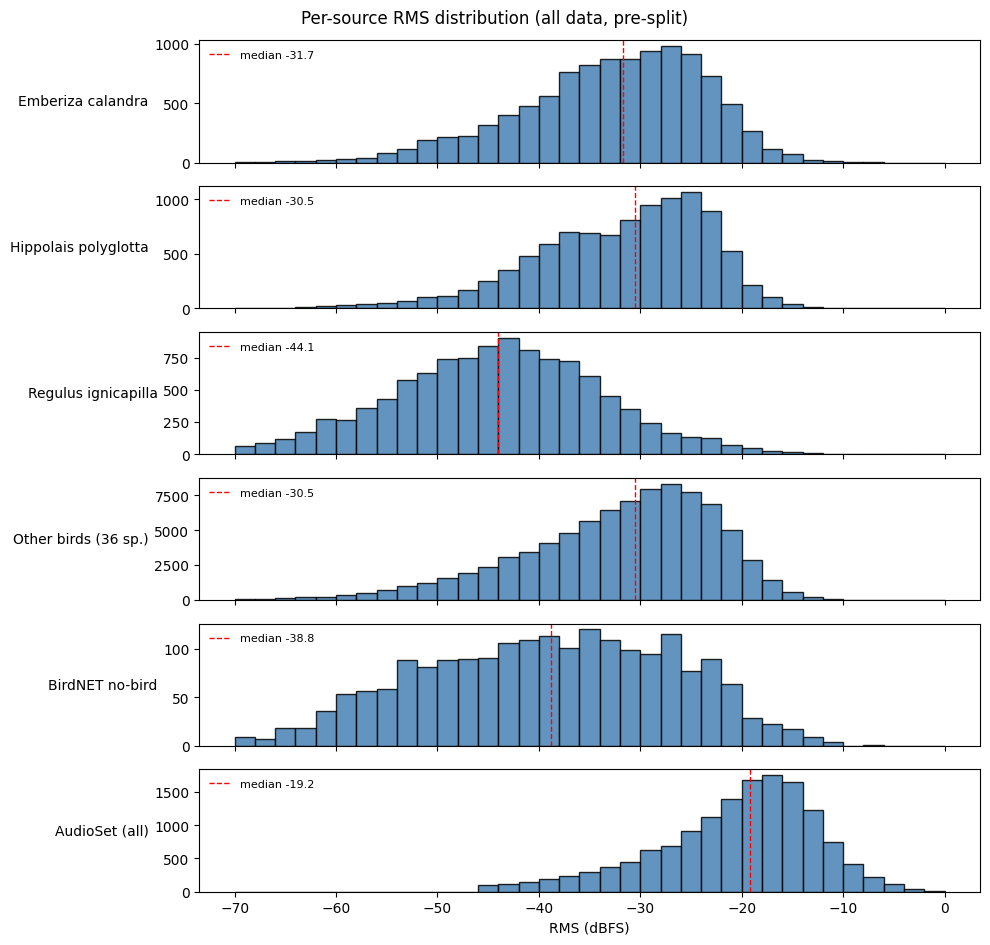

In [24]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _rms_dbfs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32)
    rms = np.sqrt(np.mean(x**2))
    return float(20.0 * np.log10(max(rms, 1e-10)))


def _scan(files: list) -> np.ndarray:
    out: list[float] = []
    for f in tqdm(files, desc=f"scan ({len(files)})", leave=False):
        try:
            x, _ = sf.read(str(f), dtype="float32", always_2d=False)
            if x.ndim > 1:
                x = x.mean(axis=-1)
            out.append(_rms_dbfs(x))
        except Exception:
            pass
    return np.array(out)


groups: list[tuple[str, np.ndarray]] = []

# One panel per target species.
for sp in TARGET_SPECIES:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        groups.append((sp, _scan(sorted(folder.glob("*.wav")))))

# Other birds aggregated.
other_files: list = []
for sp in OTHER_SPECIES:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        other_files.extend(folder.glob("*.wav"))
groups.append((f"Other birds ({len(OTHER_SPECIES)} sp.)", _scan(other_files)))

# BirdNET no-bird clips.
if BIRDNET_NO_BIRD_DIR.exists():
    groups.append(
        ("BirdNET no-bird", _scan(sorted(BIRDNET_NO_BIRD_DIR.glob("*.wav"))))
    )

# AudioSet aggregated across focus classes.
if AUDIOSET_DIR.exists():
    as_files: list = []
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            as_files.extend(d.glob("*.wav"))
    groups.append(("AudioSet (all)", _scan(as_files)))

print(
    f"{'group':<32s} {'n':>5s}  {'q05':>6s} {'q50':>6s} {'q95':>6s}  "
    f"{'min':>6s} {'max':>6s}"
)
for label, a in groups:
    if len(a) == 0:
        continue
    print(
        f"{label:<32s} {len(a):>5d}  "
        f"{np.quantile(a, 0.05):>+6.1f} {np.median(a):>+6.1f} {np.quantile(a, 0.95):>+6.1f}  "
        f"{a.min():>+6.1f} {a.max():>+6.1f}"
    )

bins = np.arange(-70, 1, 2)
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(10, max(2.0, 1.6 * n)), sharex=True)
if n == 1:
    axes = [axes]
for ax, (label, a) in zip(axes, groups):
    if len(a):
        ax.hist(a, bins=bins, color="steelblue", edgecolor="black", alpha=0.85)
        ax.axvline(
            np.median(a), color="red", lw=1, ls="--", label=f"median {np.median(a):+.1f}"
        )
        ax.legend(loc="upper left", fontsize=8, frameon=False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("RMS (dBFS)")
fig.suptitle("Per-source RMS distribution (all data, pre-split)")
plt.tight_layout()
plt.show()


# Assemble train/val/test

In [25]:
from building.data.dataset import build_task_dataset

dataset_path = build_task_dataset(
    COLLECTION_NAME,
    target_species=TARGET_SPECIES,
    non_target_species=OTHER_SPECIES,
)
print(dataset_path)

Non-target pool: 31012 clips (14506 audioset + 14506 xc_other + 2000 birdnet_no_bird)
  audioset:         take 14506 of 14506 available
  xc_other:         take 14506 of 86302 available
  birdnet_no_bird:  take 2000 of 2000 available
Processing Emberiza_calandra with 10574 clips
Training: 7398, Validation: 1567, Testing: 1609
Copied 7398 clips from Emberiza_calandra to training
Copied 1567 clips from Emberiza_calandra to validation
Copied 1609 clips from Emberiza_calandra to testing
Processing Hippolais_polyglotta with 10000 clips
Training: 6991, Validation: 1506, Testing: 1503
Copied 6991 clips from Hippolais_polyglotta to training
Copied 1506 clips from Hippolais_polyglotta to validation
Copied 1503 clips from Hippolais_polyglotta to testing
Processing Regulus_ignicapilla with 10935 clips
Training: 7658, Validation: 1638, Testing: 1639
Copied 7658 clips from Regulus_ignicapilla to training
Copied 1638 clips from Regulus_ignicapilla to validation
Copied 1639 clips from Regulus_ignicap

# Assemble cascading train/val/test

Same raw clips as `task_dataset`, but the non-target pool is split into
`non_target_bird` (other species, XC/eBird) and `no_bird` (AudioSet +
BirdNET no-bird). `task_cascading_train` reuses this collection: stage 1
groups the bird folders against `no_bird` for a binary detector;
stage 2 trains a bird-only classifier over targets + `non_target_bird`.

In [26]:
from building.data.dataset import build_cascading_dataset

cascading_path = build_cascading_dataset(
    CASCADING_COLLECTION_NAME,
    target_species=TARGET_SPECIES,
    non_target_species=OTHER_SPECIES,
)
print(cascading_path)

Cascading pools: non_target_bird=86302 no_bird=16506 (audioset_round_robin + birdnet_no_bird)
Processing Emberiza_calandra with 10574 clips
Training: 7398, Validation: 1567, Testing: 1609
Copied 7398 clips from Emberiza_calandra to training
Copied 1567 clips from Emberiza_calandra to validation
Copied 1609 clips from Emberiza_calandra to testing
Processing Hippolais_polyglotta with 10000 clips
Training: 6991, Validation: 1506, Testing: 1503
Copied 6991 clips from Hippolais_polyglotta to training
Copied 1506 clips from Hippolais_polyglotta to validation
Copied 1503 clips from Hippolais_polyglotta to testing
Processing Regulus_ignicapilla with 10935 clips
Training: 7658, Validation: 1638, Testing: 1639
Copied 7658 clips from Regulus_ignicapilla to training
Copied 1638 clips from Regulus_ignicapilla to validation
Copied 1639 clips from Regulus_ignicapilla to testing
Processing non_target_bird with 86302 clips
Training: 60407, Validation: 12937, Testing: 12958
Copied 60407 clips from non_t